# Implementing ANNs with TensorFlow - Homework 04 (Group 4)

## Assignment: MNIST math

### 2.1 Preparing MNIST math dataset

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# load the data
(train_ds, test_ds), ds_info = tfds.load ('mnist', split =['train', 'test'], as_supervised = True, with_info = True)

# only use a subset of the data to accelerate the training process
train_ds = train_ds.take(5000)
test_ds = test_ds.take(500)

c:\Users\marta\anaconda3\envs\iannwtf\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Two MNIST math datasets

In [7]:
def prepare_data(mnist, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing for the case: a + b >= 5.

  Arguments:
  mnist -- (a subset of) the MNIST dataset
  batch_size -- denotes the batch size (default is 32)
  """

  # flatten the images into vectors
  mnist = mnist.map(lambda img, target: (tf.reshape(img, (-1,)), target))
  # convert images to float32 data type
  mnist = mnist.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # project the pixel values into range [-1, 1]
  mnist = mnist.map(lambda img, target: ((img/128.)-1., target))
  # returns tuples of elements from the MNIST dataset, e.g., ((x1,y1),(x2,y2))
  zipped = tf.data.Dataset.zip((mnist.shuffle(2000), mnist.shuffle(2000)))
  # map ((x1,y1),(x2,y2)) to (x1,x2, y1==y2*) *boolean
  zipped = zipped.map(lambda x1, x2: (x1[0], x2[0], x1[1]+x2[1]>=5))
  # transform boolean target to int
  zipped = zipped.map(lambda x1, x2, target: (x1,x2, tf.cast(target, tf.int32)))
  # use batches of a given size
  zipped = zipped.batch(batch_size)
  # prefetch as many data points as we put into a batch
  zipped = zipped.prefetch(tf.data.AUTOTUNE)

  
  return mnist

# prepare training and test data in this manner
train_dataset = train_ds.apply(prepare_data)
test_dataset = test_ds.apply(prepare_data)

### 3 Building shared weight models

In [8]:
from tensorflow.python.keras.layers import Dense

class MnistModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """

  def __init__ (self, n_hidden_layers=2, hidden_layer_size=256):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    n_hidden_layers -- denotes the number of hidden layers (default is 2)
    hidden_layer_size -- denotes the number of neurons in a hidden layer (default is 256)
    """
    super().__init__()
    # instantiate the hidden layers using ReLU as activation function
    self.hidden_layers = []
    for i in range(n_hidden_layers):
      self.hidden_layers.append(tf.keras.layers.Dense(hidden_layer_size, activation=tf.nn.relu))
    # initiate the output layer with softmax as activation function
    self.output_layer = tf.keras.layers.Dense(10, activation=tf.nn.softmax)

  @tf.function
  def call (self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    output = input
    # feed the input through the network
    for i, _ in enumerate(self.hidden_layers):
      output = self.hidden_layers[i](output)
    output = self.output_layer(output)

    return output

### 4.1 Training the networks

In [9]:
def train_step (model, input, target, loss_function, optimizer):
  """
  This function defines a step during the training process.

  Arguments:
  model -- the model object representing our neural network
  input -- the input tensors to the model
  target -- the model targets
  loss_function -- the loss function of the model
  optimizer -- the model optimizer
  """
  with tf.GradientTape() as tape:
    # create the prediction
    prediction = model(input)
    # calculate the loss
    loss = loss_function(target, prediction)
    # check the accuracy
    accuracy = np.argmax(target, axis=1) == np.argmax(prediction, axis=1)
    # calculate the mean accuracy
    accuracy = np.mean(accuracy)
  # calculate the gradients
  gradients = tape.gradient(loss, model.trainable_variables)
  # apply the gradients following the optimizer
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  return loss, accuracy


def test(model, test_data, loss_function):
  """
  A function to test how the model performs on the given data.
  Returns the mean loss and accuracy.

  Arguments:
  model -- our neural network
  test_data -- the data used for testing
  loss_function -- the loss function
  """
  # lists to track the accuracies and losses
  test_accuracies = []
  test_losses = []
  # iterate over the test data
  for (input, target) in test_data:
    # create the prediction
    prediction = model(input)
    # calculate the loss
    test_loss = loss_function(target, prediction)
    # check if prediction matches the target
    test_accuracy = np.argmax(target, axis=1) == np.argmax(prediction, axis=1)
    # calculate the mean accuracy
    test_accuracy = np.mean(test_accuracy)
    # store loss and accuracy
    test_losses.append(test_loss.numpy())
    test_accuracies.append(np.mean(test_accuracy))

  # calculate the mean losses and 
  test_loss = tf.reduce_mean(test_losses)
  test_accuracy = tf.reduce_mean(test_accuracies)

  return test_loss, test_accuracy


def training(model, n_epochs, train_data, test_data, loss_function, optimizer):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  train_data -- the data set used for training the model
  test_data -- the data set used for testing the model
  loss_function -- the loss function
  optimizer -- the optimizer
  """
  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # check how our model performs on training data before training
  train_loss, train_accuracy = test(model, train_dataset, loss_function)
  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  # check how our model performs on test data before training
  test_loss, test_accuracy = test(model, test_dataset, loss_function)
  test_losses.append(test_loss)
  test_accuracies.append(test_accuracy)

  # train for given number of epochs
  for epoch in range(n_epochs):
    # print the accuracy before the current epoch
    print(f'Epoch: {str(epoch)} starting with accuracy {test_accuracies[-1]}')
    
    # lists to track losses and accuracies
    epoch_losses = []
    epoch_accuracies = []
    
    # iterate over all images in the data set
    for input, target in train_dataset:
      # update the network and record loss and accuracy
      train_loss, train_accuracy = train_step(model, input, target, loss_function, optimizer)
      epoch_losses.append(train_loss)
      epoch_accuracies.append(train_accuracy)

    # calculate the mean loss and accuracy
    train_losses.append(tf.reduce_mean(epoch_losses))
    train_accuracies.append(tf.reduce_mean(epoch_accuracies))
    
    # track loss and accuracy on the test data
    test_loss, test_accuracy = test(model, test_dataset, loss_function)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

  return train_losses, train_accuracies, test_losses, test_accuracies

### 4.2 Training the networks

In [10]:
tf.keras.backend.clear_session()

# hyperparameters for the training process
num_epochs = 10
learning_rate = 0.1

# instantiate the model
model = MnistModel()
# our loss function will be categorical cross entropy loss
cross_entropy_loss = tf.keras.losses.CategoricalCrossentropy()
# use stochastic gradient descent as optimizer
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate)

# train the base model
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer)

ValueError: Exception encountered when calling layer "mnist_model" "                 f"(type MnistModel).

in user code:

    File "C:\Users\marta\AppData\Local\Temp\ipykernel_13596\225478724.py", line 35, in call  *
        output = self.hidden_layers[i](output)
    File "c:\Users\marta\anaconda3\envs\iannwtf\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\marta\anaconda3\envs\iannwtf\lib\site-packages\keras\engine\input_spec.py", line 250, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 of layer "dense" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (784,)


Call arguments received by layer "mnist_model" "                 f"(type MnistModel):
  • input=tf.Tensor(shape=(784,), dtype=float32)

### 4.3 Visualization

In [ ]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  """
  # create the plot grid
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9,6))
  # plot training and test losses and accuracies
  line1, = axes[0].plot(train_losses, color="orange")
  line2, = axes[0].plot(test_losses, color="green")
  line3, = axes[1].plot(train_accuracies, color="orange")
  line4, = axes[1].plot(test_accuracies, color="green")
  # set the axis limits and labels
  axes[0].set(ylim=[0, 3], ylabel="Loss")
  axes[1].set(ylim=[0, 1], xlabel="Training steps", ylabel="Accuracy")
  # create the legend
  axes[0].legend((line1, line2), ("Training","Test"))

  fig.suptitle("Training Progress")

  plt.show()

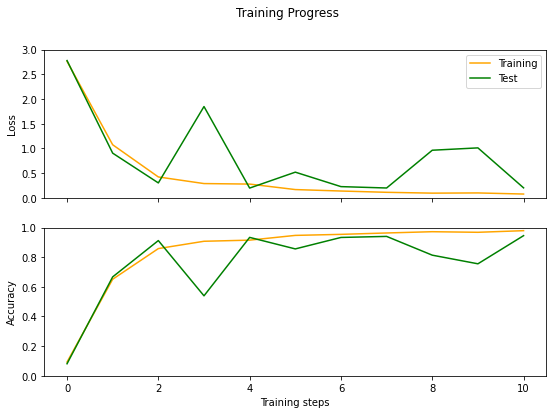

In [ ]:
# show the losses and accuracies of our base model throughout the training process
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

### 5 Experiments

Run training with a classic SGD optimizer (without momentum) and an Adam Optimizer.

For an outstanding submission, you are required to also add SGD with Momentum,RMSProp and AdaGrad optimizers and compare the training results by plotting them cleanly side-by-side.

**Training with a SGD optimizer without momentum and an Adam Optimizer**

**SGD with Momentum,RMSProp and AdaGrad optimizers?**